In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os, scipy
import matplotlib.colors as mcolors
import networkx as nx
import pickle

if os.getcwd().split(os.sep)[-1] == "examples":
    os.chdir('..')
    os.chdir('..')
    os.chdir('..')
    os.chdir('..')

# We import the model, stimuli, and the optimal control package
from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.optimal_control import oc_wc, cost_functions
from neurolib.optimal_control.oc_utils.plot_oc import plot_oc_nw

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

options = {
    'node_color': 'lightgray',
    'node_size': 1000,
    'width': 2,
    'arrowstyle': '-|>',
    'arrowsize': 20,
    'font_size' : 20,
    'font_weight' : 'bold',
    }

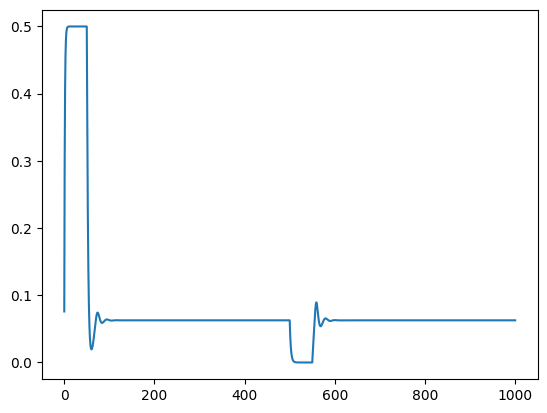

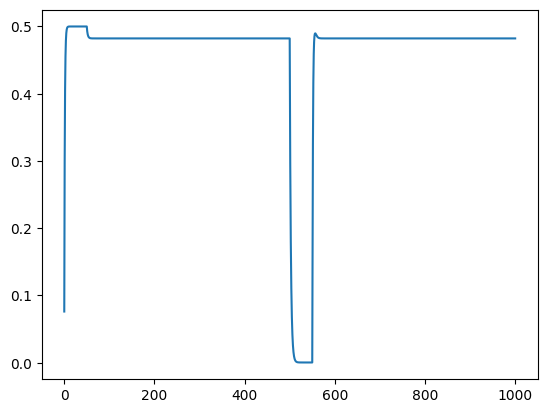

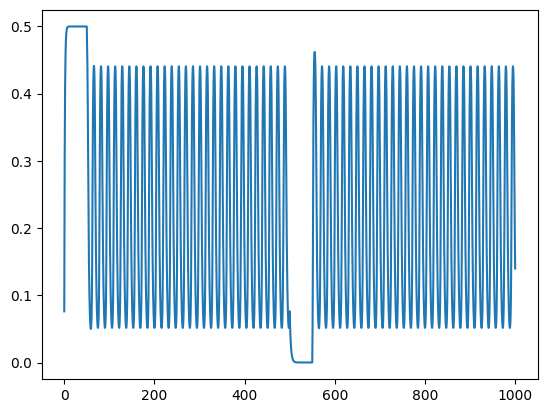

period =  15.67777777777778


In [2]:
comp_points = [[1., 0.5], [3., 0.5], [2., 0.5]]

N = 1

colors = []
n = 0
for col in mcolors.TABLEAU_COLORS:
    colors.append(col)
    n += 1
    if n >= N: break

model = WCModel()

dt = 0.1
model.params['dt'] = dt # Integration time step, ms
model.params['duration'] = 1. * 1000 # Simulation time, ms
model.params.signalV = 1.

zero_input = ZeroInput().generate_input(duration=model.params['duration']+model.params.dt, dt=model.params.dt)
rect_input = np.vstack( (zero_input)*2 )
rect_input[0,:500] = 5.
rect_input[0,5000:5500] = -5.

for p in comp_points:
    model.params["exc_ext"] = p[0] + rect_input[0,:]
    model.params["inh_ext"] = p[1]
    model.run()

    for n in range(N):
        plt.plot(model.t, model.exc[n,:], color=colors[n])
    plt.show()

    if p[0] == 2.:

        peaks = scipy.signal.find_peaks(model.exc[0,2000:5000])[0]
        plist = []
        for pind in range(1, len(peaks)):
            plist.append(model.params.dt * (peaks[pind]-peaks[pind-1]))

        period = np.mean(plist)
        print("period = ", period)


In [3]:
def getperiods(x, prominence):
    timing_list = [None] * N
    periods_list = [None] * N

    for n in range(N):
        timing_list[n] = scipy.signal.find_peaks(x[n, 0, 300:], prominence=prominence)[0]
        periods_list[n] = []
        if len(timing_list[n]) < 3:
            continue
        for pind in range(1, len(timing_list[n])):
            periods_list[n].append(model.params.dt * (timing_list[n][pind]-timing_list[n][pind-1]))

    return timing_list, periods_list

In [4]:
controlmat = np.zeros((N,2))
controlmat[:,0] = 1.

costmat = np.zeros((N, 2))
costmat[:,0] = 1.

duration = 200.
model.params.duration = duration
zero_input0 = ZeroInput().generate_input(duration=duration+model.params.dt, dt=model.params.dt)
zero_input = np.vstack( ([zero_input0]*2) )[np.newaxis,:,:]
zero_control = np.vstack( ([zero_input]*N))

print(zero_input0.shape, zero_input.shape, zero_control.shape)

w2_array = [1e-3, 1e-5]

results = dict()
results["controls"] = [ [ [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ],  ], 
                        [ [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ],  ], 
                        [ [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ],  ], 
]

target_array = [0.5*period, 0.9*period, period, 1.1*period, 1.6*period]
results["periods"] =  [ [ [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ],  ], 
                        [ [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ],  ], 
                        [ [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ],  ], 
]
results["timings"] =  [ [ [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ],  ], 
                        [ [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ],  ], 
                        [ [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ], [ [None, None], [None, None], [None, None], [None, None] ],  ], 
]

(1, 2001) (1, 2, 2001) (1, 2, 2001)


In [11]:
it = 100
pr = np.arange(0,101,10)
maxstr = 10.
nmaxdel = model.getMaxDelay()

proms = [0.01, 0.001]

init_control = zero_control.copy()
dir = "images_1n"

pind =  0
itar =  0
imet =  0
iw =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.06589492166367379
Cost in iteration 10: -0.06596505274594452
Cost in iteration 20: -0.06603726751033132
Cost in iteration 30: -0.06613060455799893
Cost in iteration 40: -0.06620602804295447
Cost in iteration 50: -0.06629315156568237
Cost in iteration 60: -0.06638458617014675
Cost in iteration 70: -0.06645909261967178
Cost in iteration 80: -0.06653553819546881
Cost in iteration 90: -0.06661160671861835
Cost in iteration 100: -0.06668719480994614
Final cost : -0.06668719480994614


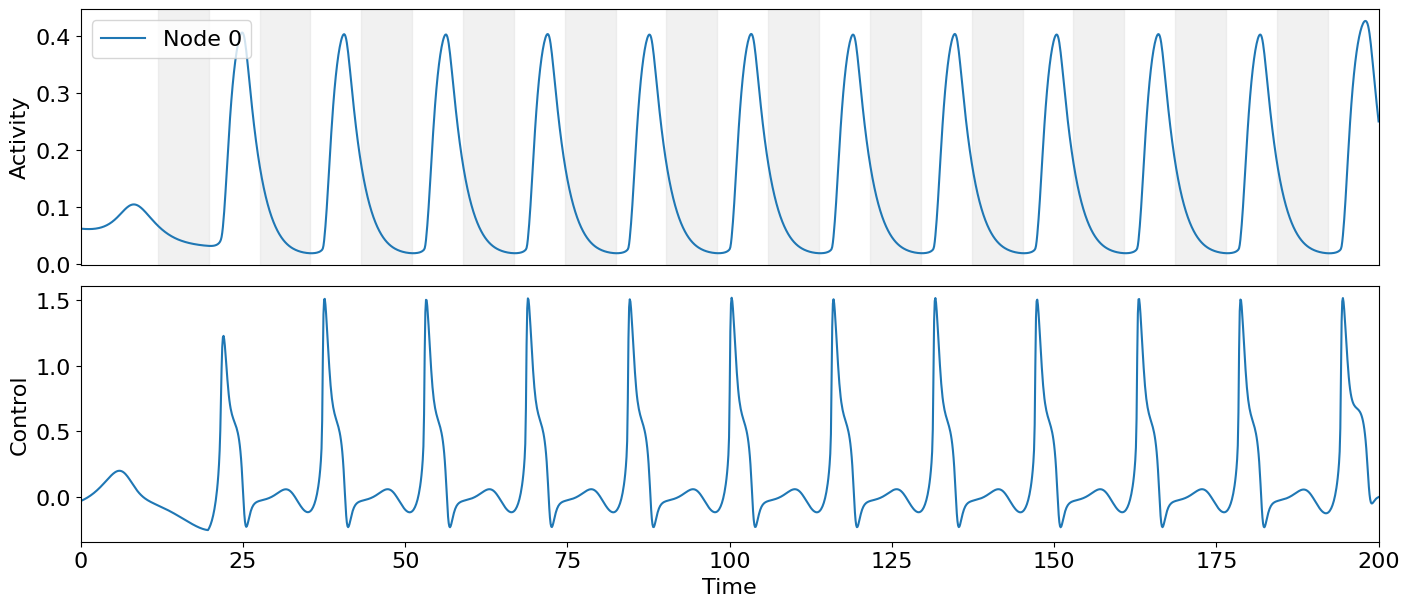

iw =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.17505942678919648
Cost in iteration 10: -0.17506282690313757
Cost in iteration 20: -0.1750918422013125
Cost in iteration 30: -0.1751102531381753
Cost in iteration 40: -0.17513084971336437
Cost in iteration 50: -0.17515166794553494
Cost in iteration 60: -0.1751612264894896
Cost in iteration 70: -0.17518095750996648
Cost in iteration 80: -0.1752033309332756
Cost in iteration 90: -0.17522682235254158
Cost in iteration 100: -0.17525195488224982
Final cost : -0.17525195488224982


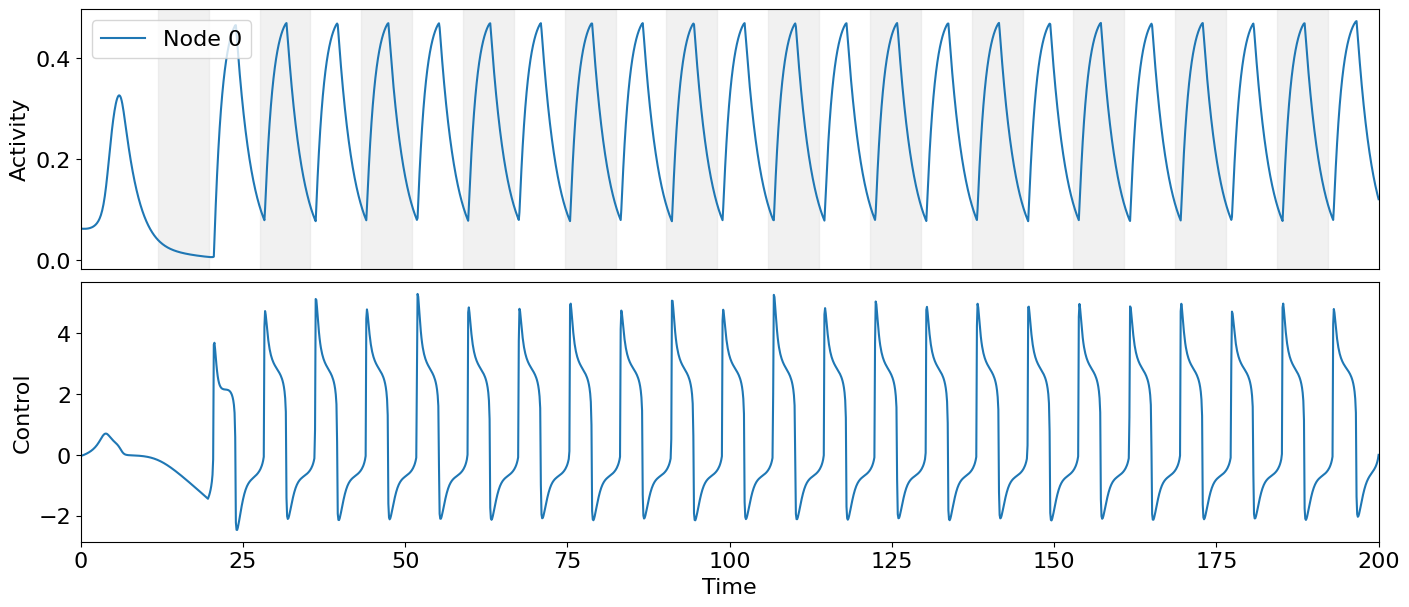

itar =  1
imet =  0
iw =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.16878864842173466
Cost in iteration 10: -0.16878864842439814
Cost in iteration 20: -0.1687886484251585
Cost in iteration 30: -0.16878864842540223
Cost in iteration 40: -0.16878864842546176
Converged in iteration 49 with cost -0.16878864842547467
Final cost : -0.16878864842547467


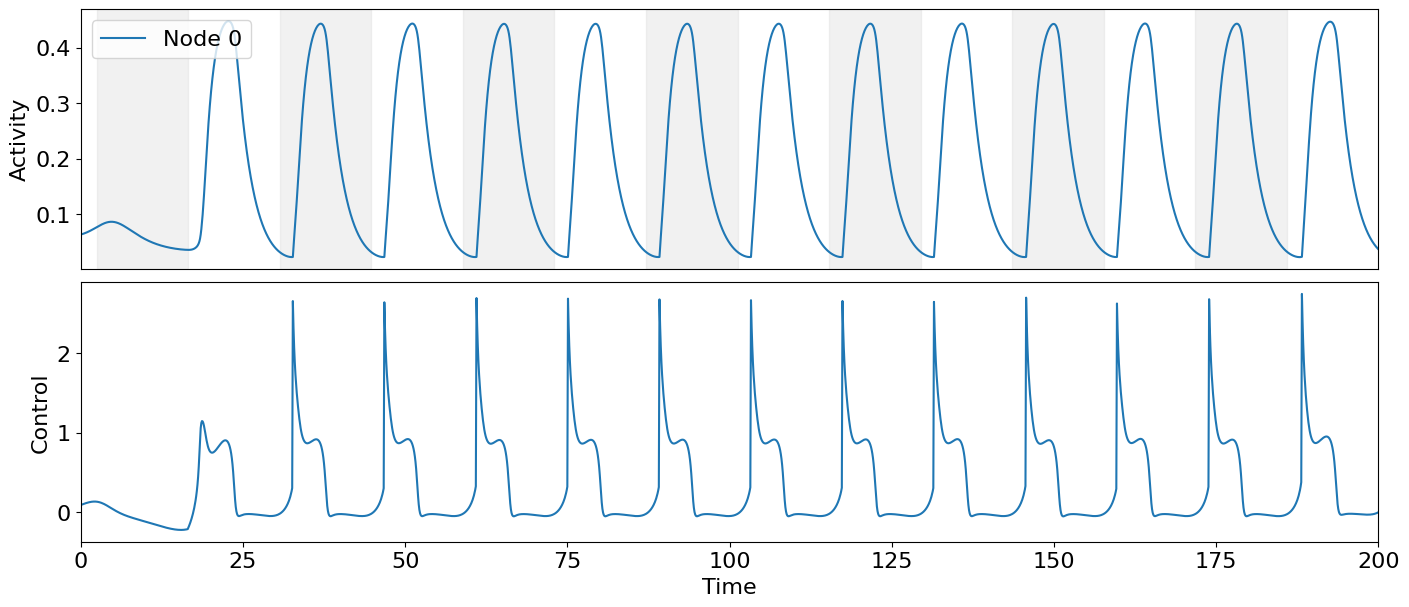

iw =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.24140193456047626
Cost in iteration 10: -0.24140276004618985
Cost in iteration 20: -0.24141113104508446
Cost in iteration 30: -0.24141572563573088
Cost in iteration 40: -0.24142106658227852
Cost in iteration 50: -0.24142600808496628
Cost in iteration 60: -0.24143158669475587
Cost in iteration 70: -0.24143637481288682
Cost in iteration 80: -0.24144084149874512
Cost in iteration 90: -0.2414463326132579
Cost in iteration 100: -0.24145273354589944
Final cost : -0.24145273354589944


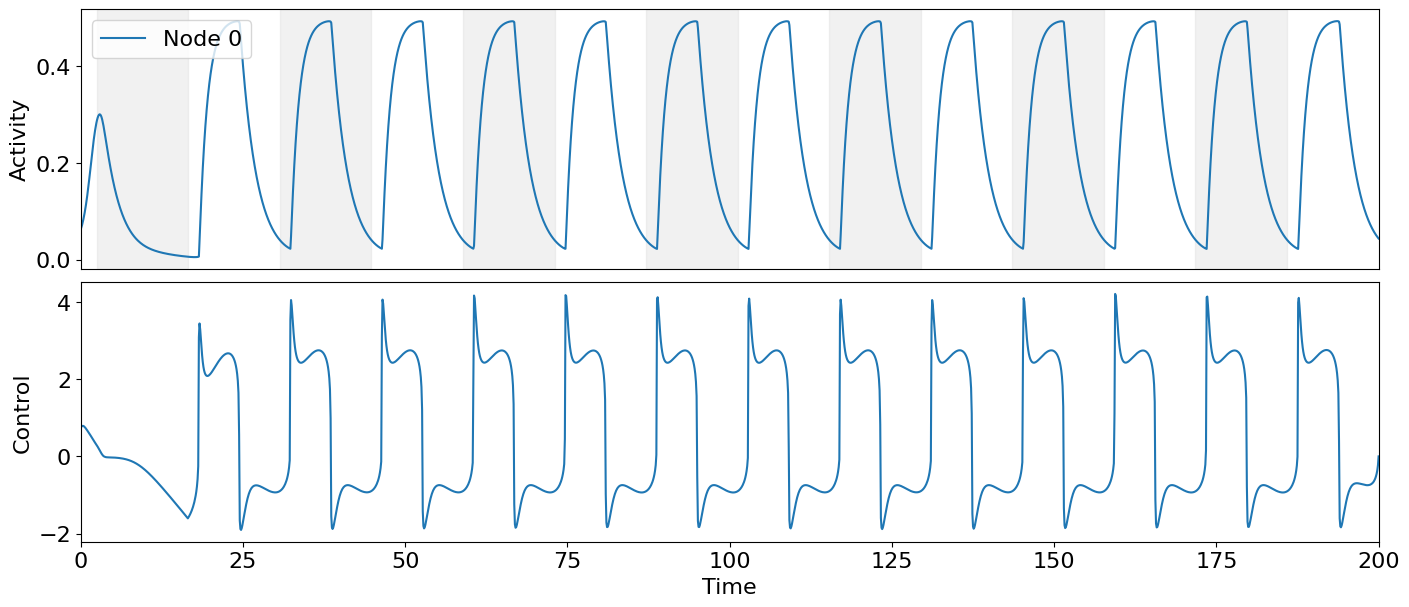

itar =  2
imet =  0
iw =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.17955001532410872
Cost in iteration 10: -0.17955001532442852
Converged in iteration 16 with cost -0.17955001532443504
Final cost : -0.17955001532443504


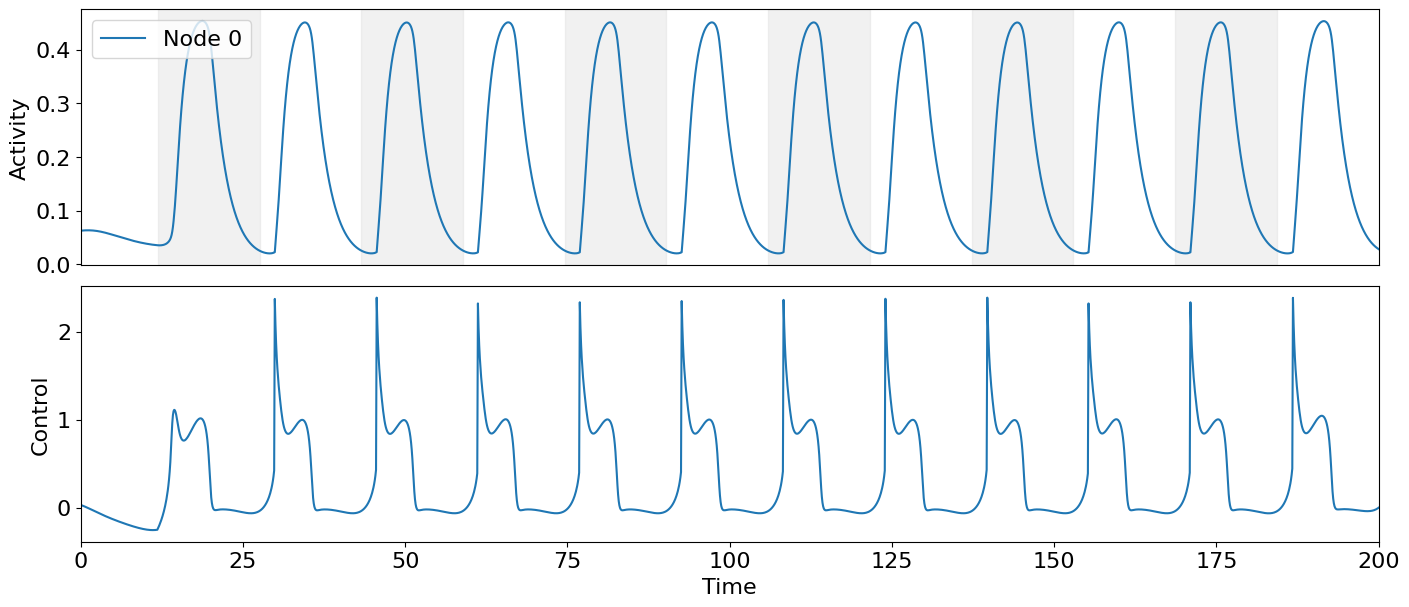

iw =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.25079246520575926
Cost in iteration 10: -0.25079276545905405
Cost in iteration 20: -0.25080157594144364
Cost in iteration 30: -0.2508055921415991
Cost in iteration 40: -0.25080915688317645
Cost in iteration 50: -0.2508130916994181
Cost in iteration 60: -0.2508163011853761
Cost in iteration 70: -0.25081958633736584
Cost in iteration 80: -0.25082338887941447
Cost in iteration 90: -0.2508276121226387
Cost in iteration 100: -0.2508321660799552
Final cost : -0.2508321660799552


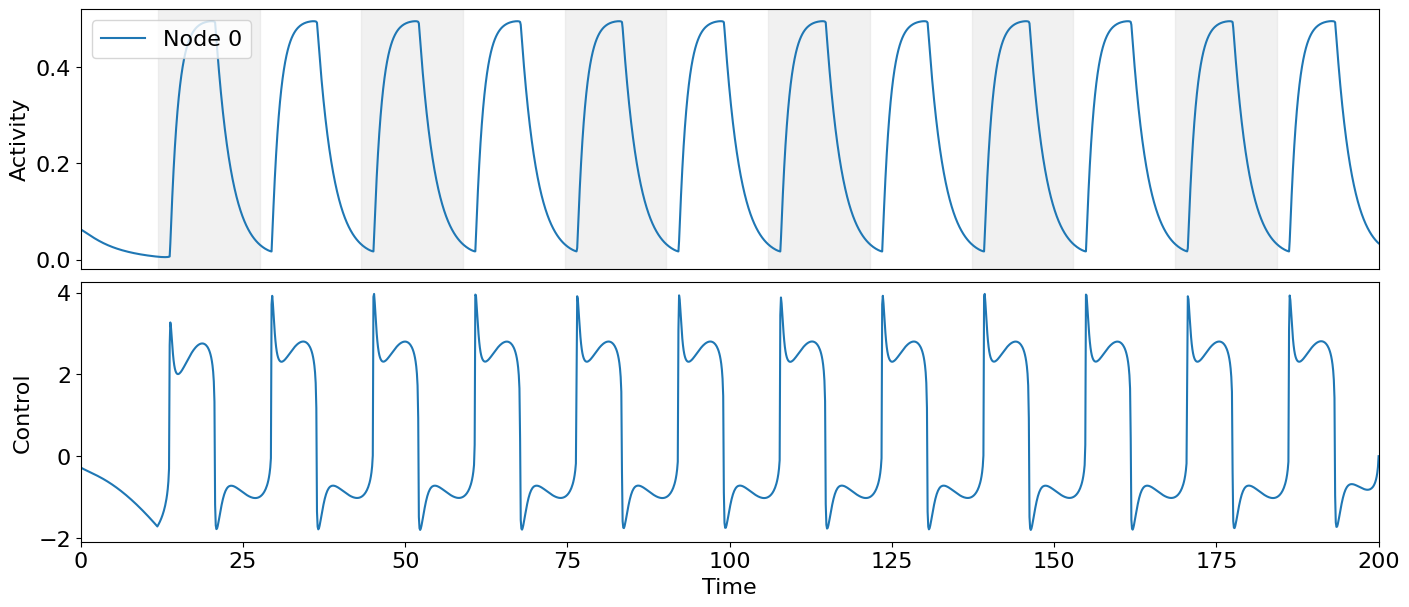

itar =  3
imet =  0
iw =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.1870139163017238
Cost in iteration 10: -0.18701402324365252
Cost in iteration 20: -0.1870140668801524
Cost in iteration 30: -0.18701407805215478
Cost in iteration 40: -0.18701407986766558
Cost in iteration 50: -0.18701408018870092
Cost in iteration 60: -0.18701408025731434
Cost in iteration 70: -0.18701408026776323
Cost in iteration 80: -0.18701408026955924
Cost in iteration 90: -0.18701408026994293
Cost in iteration 100: -0.18701408027000038
Final cost : -0.18701408027000038


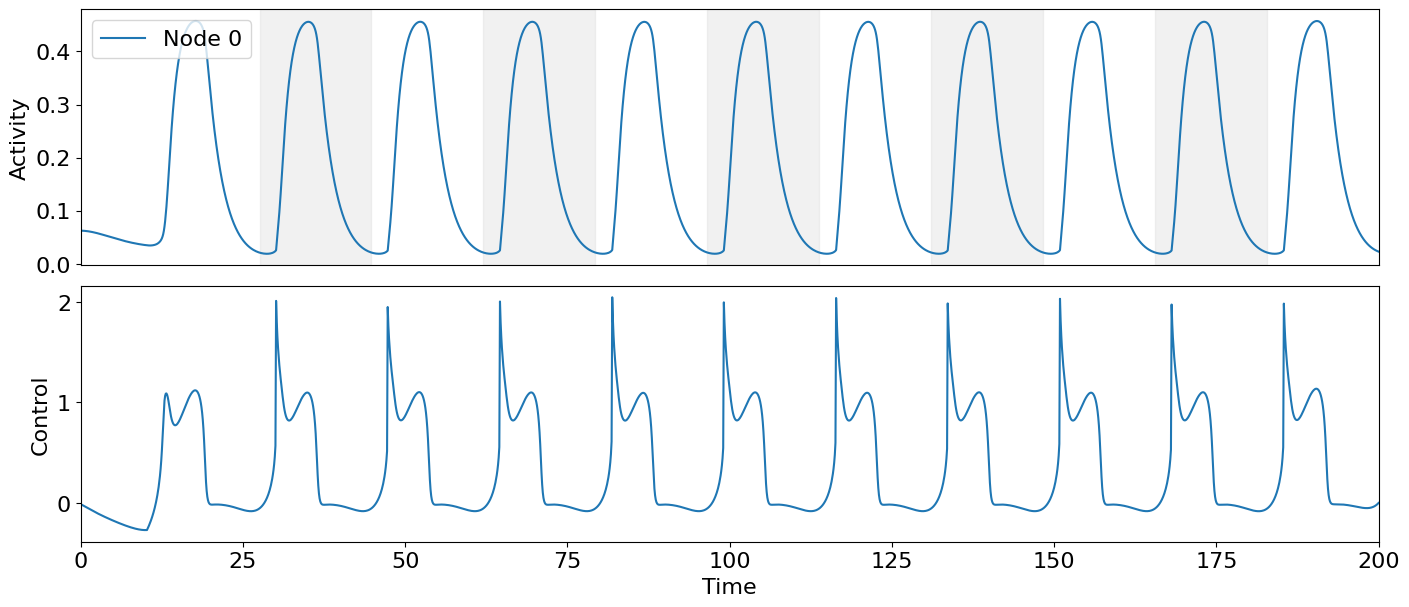

iw =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.25856580646167465
Cost in iteration 10: -0.25856607813109955
Cost in iteration 20: -0.2585712035771387
Cost in iteration 30: -0.2585746837073765
Cost in iteration 40: -0.2585770204300448
Cost in iteration 50: -0.2585791562713138
Cost in iteration 60: -0.2585807130066664
Cost in iteration 70: -0.2585822831799779
Cost in iteration 80: -0.25858451745965977
Cost in iteration 90: -0.25858723011819207
Cost in iteration 100: -0.25859079724525486
Final cost : -0.25859079724525486


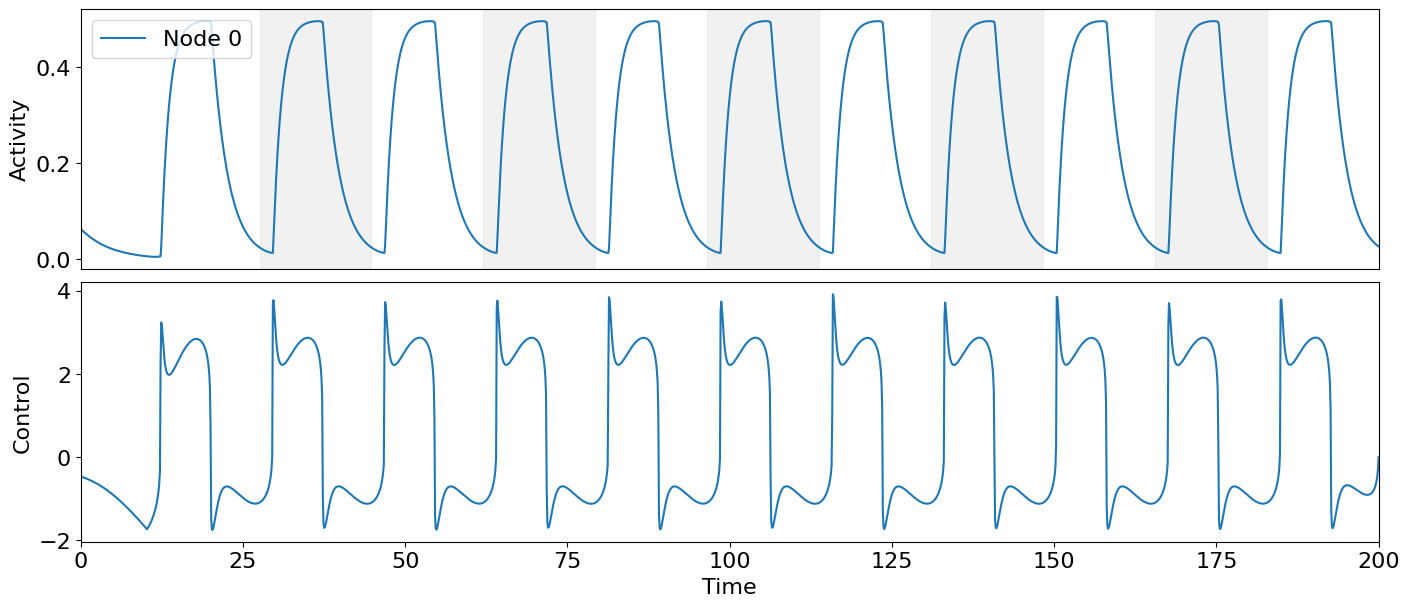

itar =  4
imet =  0
iw =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.20051701710066214
Cost in iteration 10: -0.20052047043026827
Cost in iteration 20: -0.20052323471240482
Cost in iteration 30: -0.20052583581003527
Cost in iteration 40: -0.200528272137942
Cost in iteration 50: -0.2005305343805934
Cost in iteration 60: -0.20053295417928424
Cost in iteration 70: -0.20053508927924318
Cost in iteration 80: -0.20053709819438206
Cost in iteration 90: -0.20053897906093382
Cost in iteration 100: -0.2005407251729408
Final cost : -0.2005407251729408


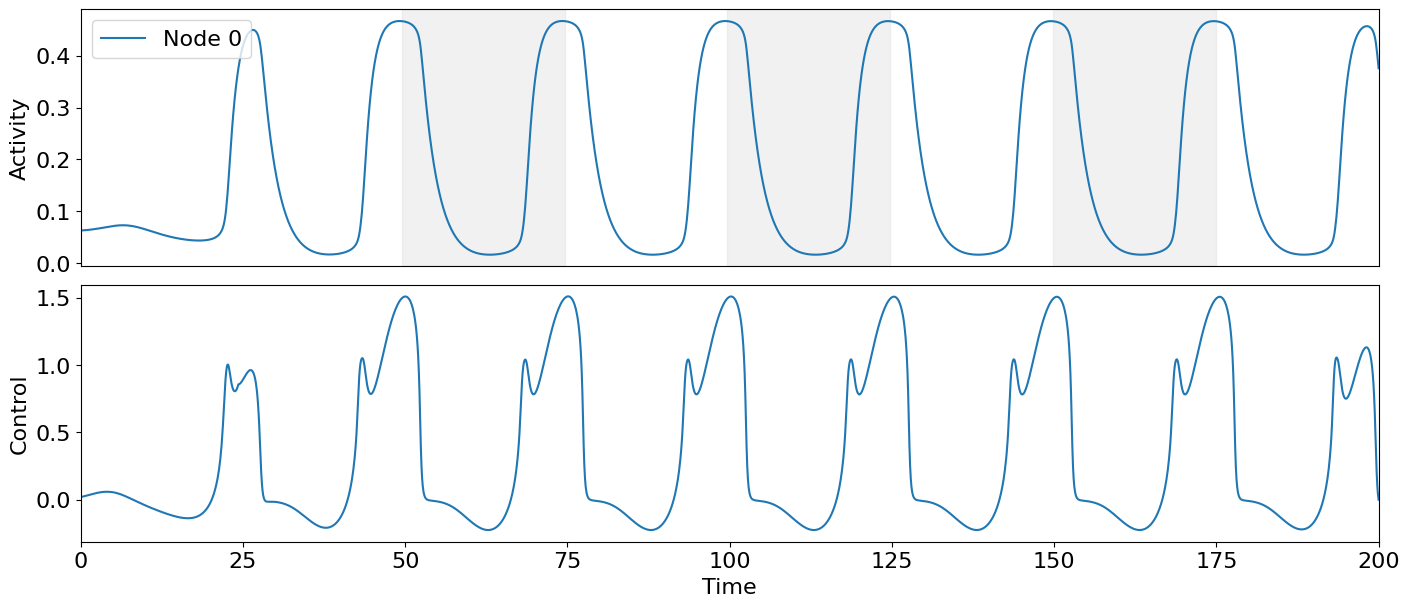

iw =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.2820761093200457
Converged in iteration 3 with cost -0.2820761093200458
Final cost : -0.2820761093200458


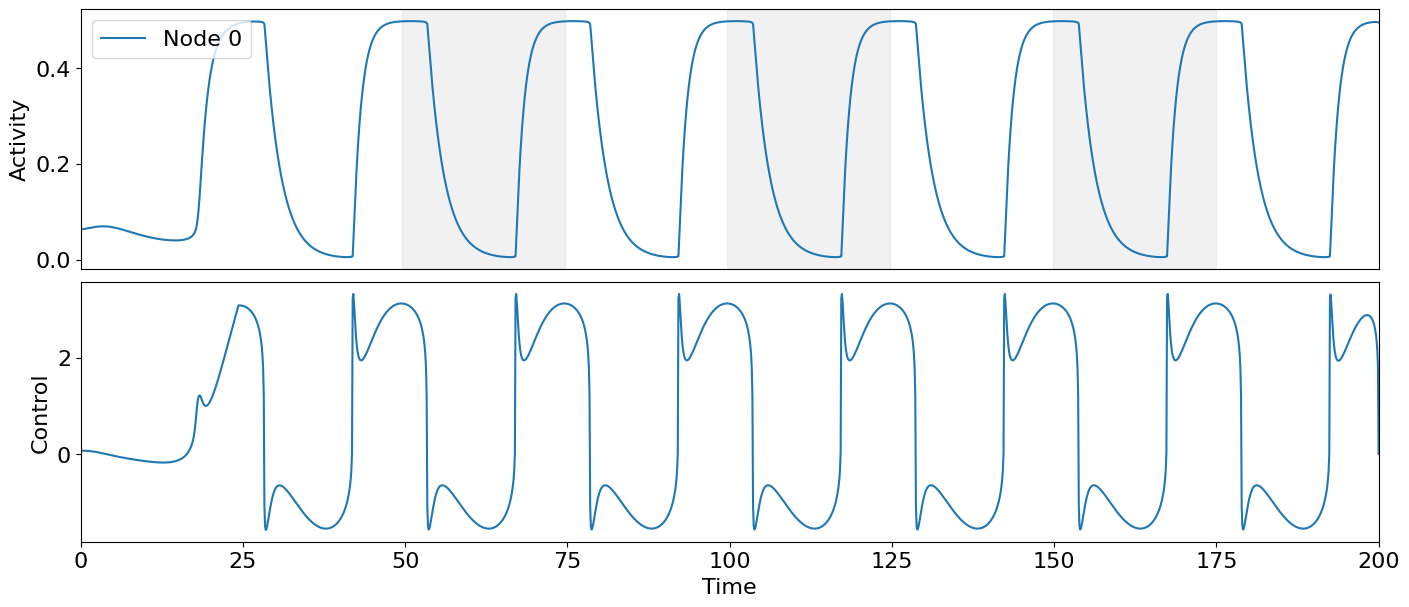

pind =  1
itar =  0
imet =  0
iw =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.07063882348325934
Cost in iteration 10: -0.07063901099145918
Cost in iteration 20: -0.07063919829542528
Cost in iteration 30: -0.07063938538609243
Cost in iteration 40: -0.07063957225127598
Cost in iteration 50: -0.07063975887536714
Cost in iteration 60: -0.07063994523887786
Cost in iteration 70: -0.0706401497847174
Cost in iteration 80: -0.07064033728780772
Cost in iteration 90: -0.0706405247297841
Cost in iteration 100: -0.07064071210665833
Final cost : -0.07064071210665833


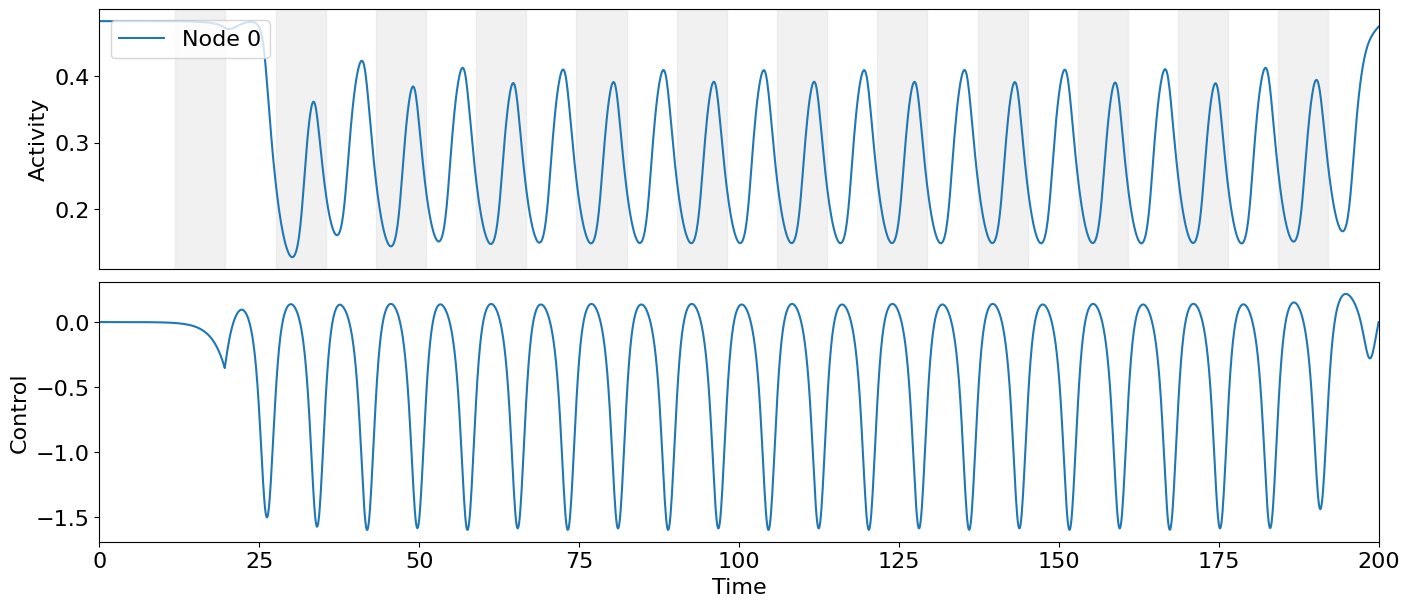

iw =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.06707261430073538
Cost in iteration 10: -0.06707533877265297
Cost in iteration 20: -0.06707797028982128
Cost in iteration 30: -0.06708037902989354
Cost in iteration 40: -0.06708298769048422
Cost in iteration 50: -0.06708537973541794
Cost in iteration 60: -0.06708748225194436
Cost in iteration 70: -0.0670899579335788
Cost in iteration 80: -0.0670921584400626
Cost in iteration 90: -0.0670942982059241
Cost in iteration 100: -0.06709618103957879
Final cost : -0.06709618103957879


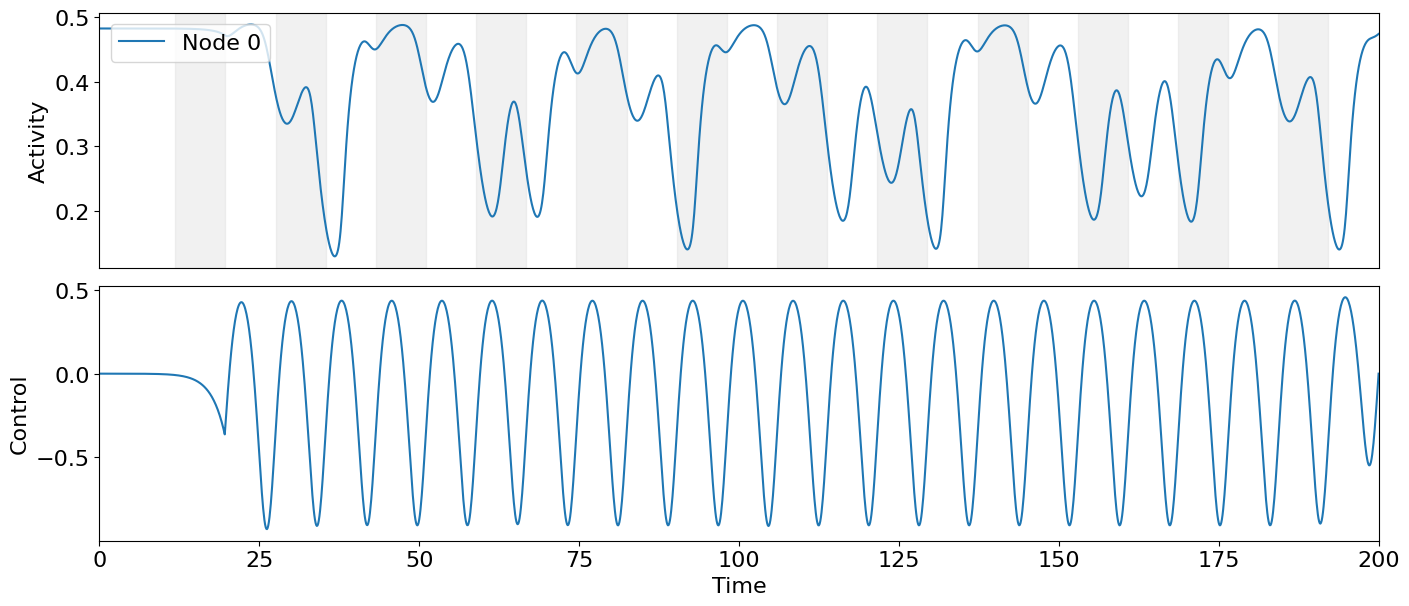

itar =  1
imet =  0
iw =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.18637668547686292
Cost in iteration 10: -0.1863979183043839
Cost in iteration 20: -0.18641488813664553
Cost in iteration 30: -0.1864308118247131
Cost in iteration 40: -0.18644337467146474
Cost in iteration 50: -0.18645625478646213
Cost in iteration 60: -0.18646713943366788
Cost in iteration 70: -0.1864772906437844
Cost in iteration 80: -0.18648649459894073
Cost in iteration 90: -0.18649566932275424
Cost in iteration 100: -0.18650387170315988
Final cost : -0.18650387170315988


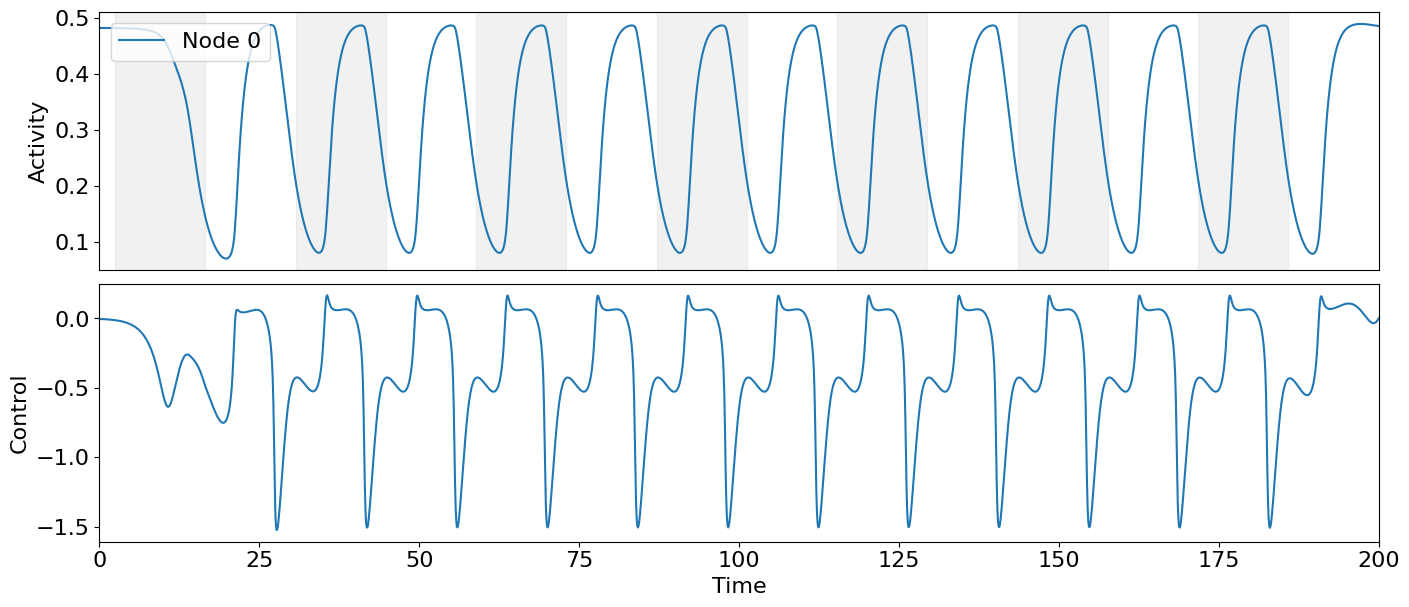

iw =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.2420045224231376
Cost in iteration 10: -0.24201124392458484
Cost in iteration 20: -0.2420287556141002
Cost in iteration 30: -0.24204074622632057
Cost in iteration 40: -0.24205185448903418
Cost in iteration 50: -0.24206329559294143
Cost in iteration 60: -0.2420747010034353
Cost in iteration 70: -0.24208625877416892
Cost in iteration 80: -0.24209827980264634
Cost in iteration 90: -0.24211062175368486
Cost in iteration 100: -0.24212254282364512
Final cost : -0.24212254282364512


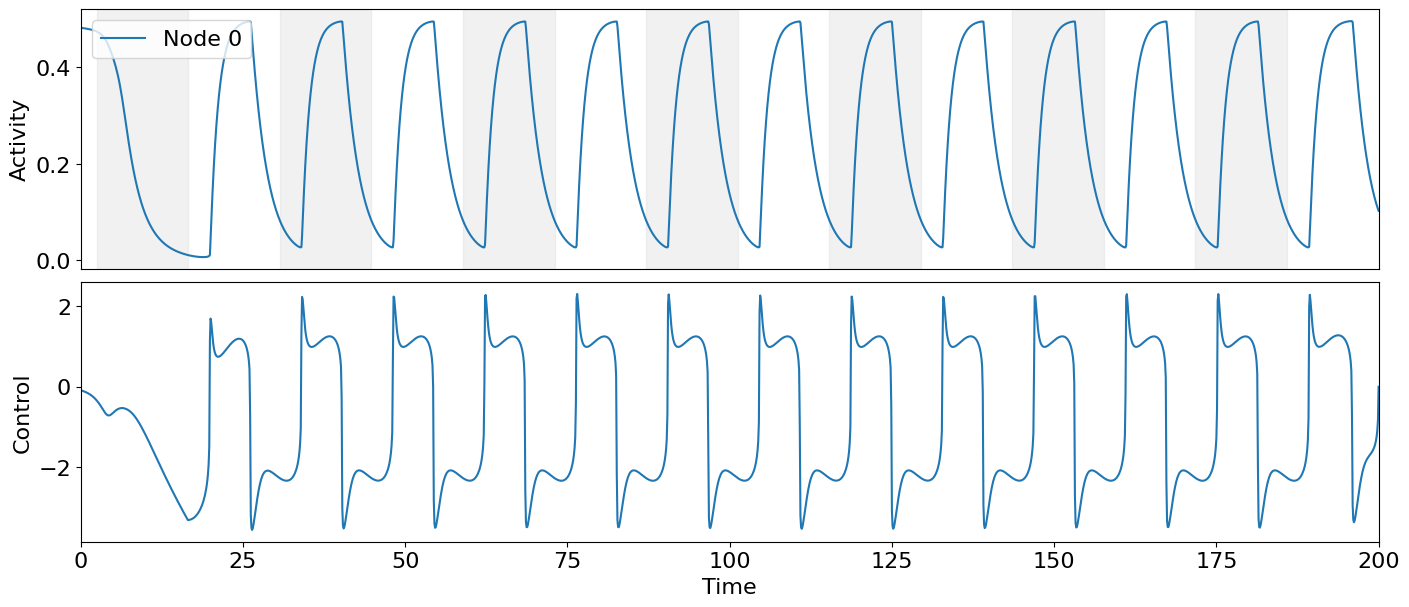

itar =  2
imet =  0
iw =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.19459315567022134
Cost in iteration 10: -0.19459337864694023
Cost in iteration 20: -0.19459362262021584
Cost in iteration 30: -0.19459390899485607
Cost in iteration 40: -0.19459416110936045
Cost in iteration 50: -0.19459438805160773
Cost in iteration 60: -0.19459466274825685
Cost in iteration 70: -0.19459493989130963
Cost in iteration 80: -0.1945952316360768
Cost in iteration 90: -0.19459549146202498
Cost in iteration 100: -0.19459576559578606
Final cost : -0.19459576559578606


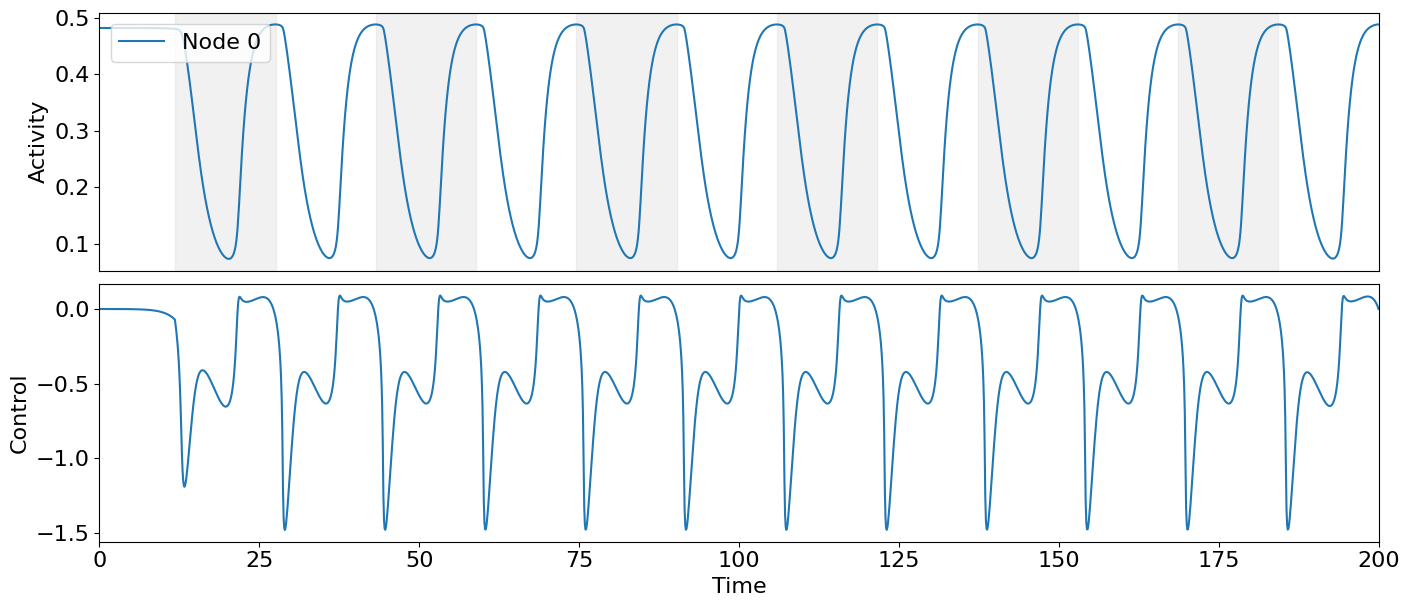

iw =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.251344378333589
Cost in iteration 10: -0.25135483811127546
Cost in iteration 20: -0.25142377865330345
Cost in iteration 30: -0.25147645247506567
Cost in iteration 40: -0.25152455135433044
Cost in iteration 50: -0.25156933259320635
Cost in iteration 60: -0.2516193310010564
Cost in iteration 70: -0.25166972168904383
Cost in iteration 80: -0.2517235443972589
Cost in iteration 90: -0.251778636582536
Cost in iteration 100: -0.2518354954475832
Final cost : -0.2518354954475832


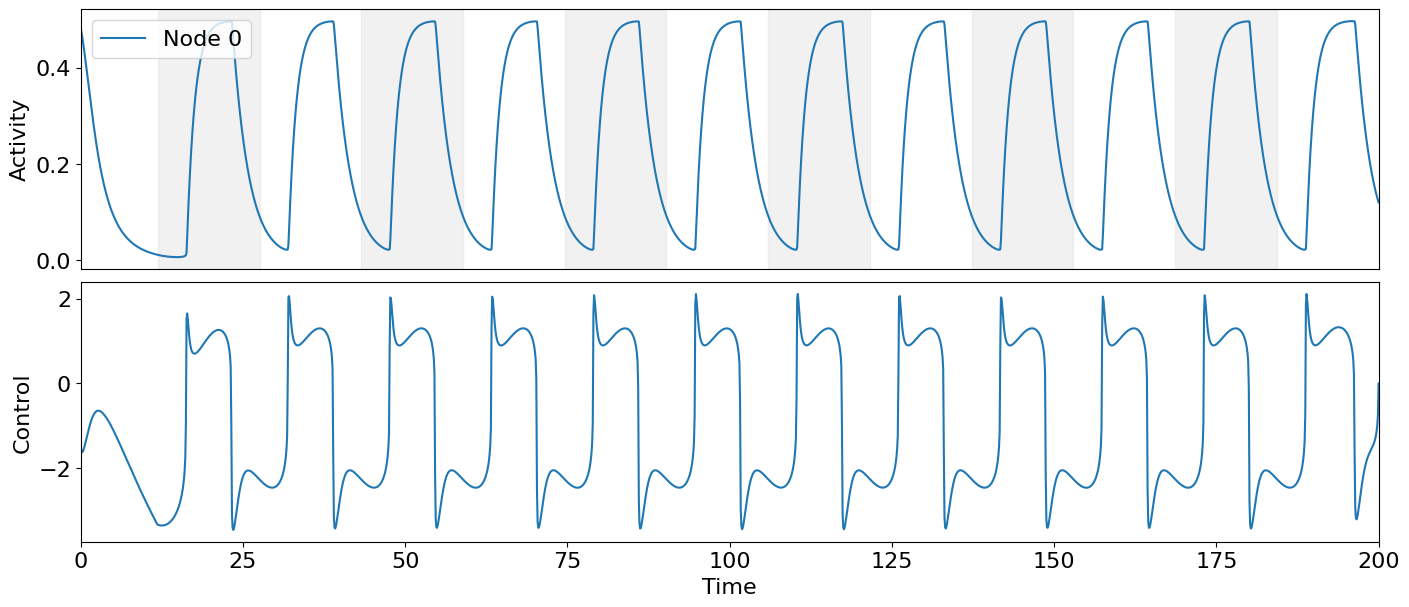

itar =  3
imet =  0
iw =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.19888453616357948
Cost in iteration 10: -0.19895108955436003
Cost in iteration 20: -0.1990105488871804
Cost in iteration 30: -0.1990611287900706
Cost in iteration 40: -0.19910486827180615
Cost in iteration 50: -0.19915119347757765
Cost in iteration 60: -0.19919078036039128
Cost in iteration 70: -0.19922425797911975
Cost in iteration 80: -0.19925859329093662
Cost in iteration 90: -0.19929195951511877
Cost in iteration 100: -0.19932187956180136
Final cost : -0.19932187956180136


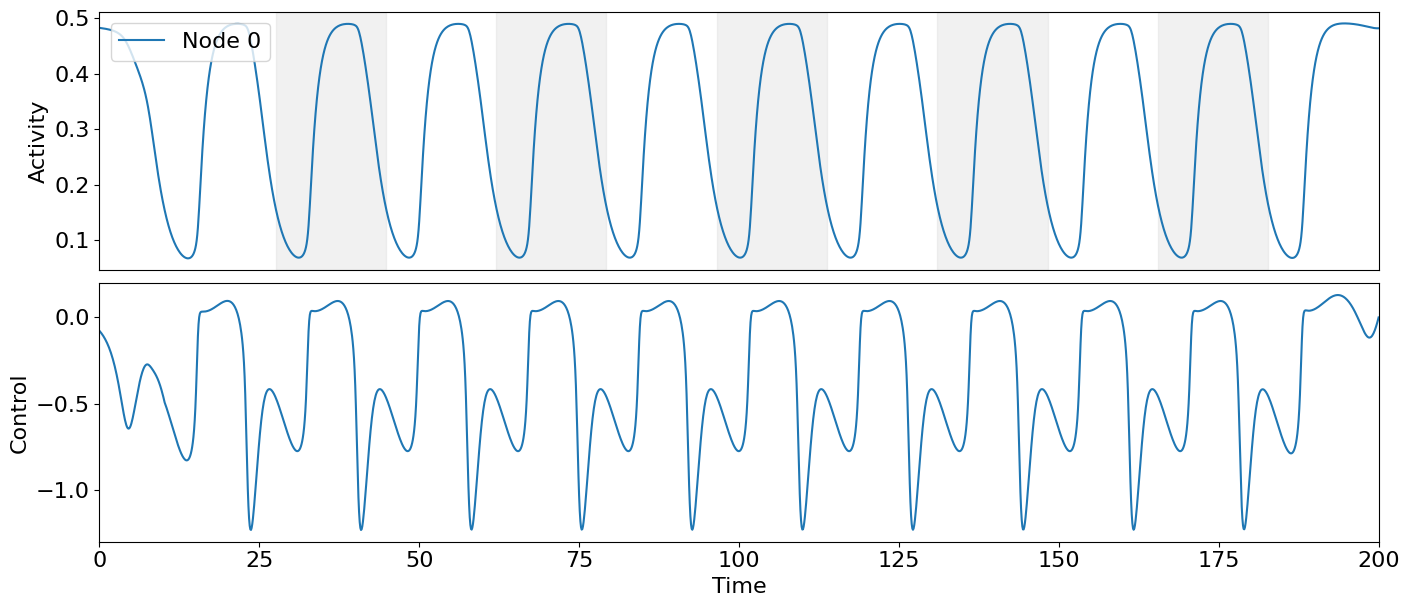

iw =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.26069865541345655
Cost in iteration 10: -0.2607197906773824
Cost in iteration 20: -0.26089977008779286
Cost in iteration 30: -0.26100592926328864
Cost in iteration 40: -0.2611032837627212
Cost in iteration 50: -0.2611994049217392
Cost in iteration 60: -0.26126628111517036
Cost in iteration 70: -0.26130874844988977
Cost in iteration 80: -0.26133910377988157
Cost in iteration 90: -0.2613543788612628
Cost in iteration 100: -0.2613663109536829
Final cost : -0.2613663109536829


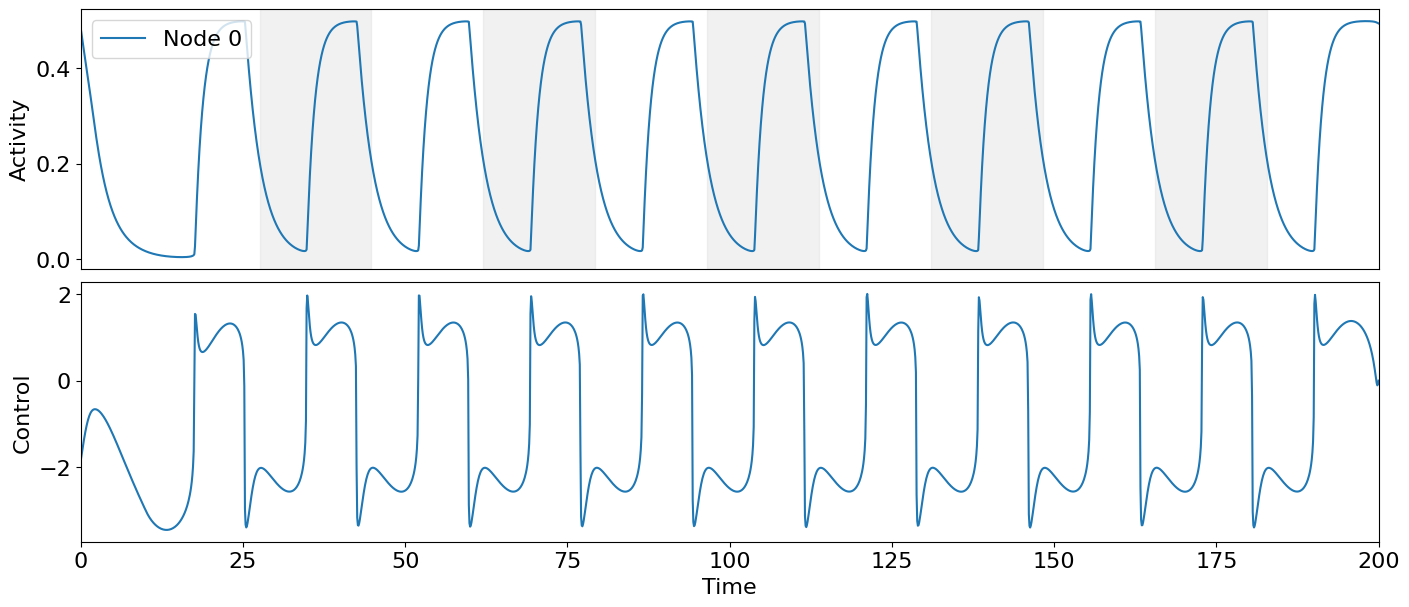

itar =  4
imet =  0
iw =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.20707694317954076
Cost in iteration 10: -0.2070835705725719
Cost in iteration 20: -0.20708983997793817
Cost in iteration 30: -0.20709730463909623
Cost in iteration 40: -0.20710410194723916
Cost in iteration 50: -0.2071083982699417
Cost in iteration 60: -0.2071128927060817
Cost in iteration 70: -0.2071164374016723
Cost in iteration 80: -0.20711969667739577


In [12]:
for pind in range(len(comp_points)):

    print("pind = ", pind)

    p = comp_points[pind]
    
    testd = 1000.
    model.params.duration = testd
    test_input = ZeroInput().generate_input(duration=testd+model.params.dt, dt=model.params.dt)
    model.params["exc_ext"] = test_input + p[0]
    model.params["inh_ext"] = test_input + p[1]
    model.run()

    einit = np.zeros((N, nmaxdel+1))
    iinit = np.zeros((N, nmaxdel+1))


    for n in range(N):
        einit[n,:] = model.exc[n,-1]
        iinit[n,:] = model.inh[n,-1]

    model.params.duration = duration

    model.params["exc_ext"] = zero_control[:,0,:] + p[0]
    model.params["inh_ext"] = zero_control[:,0,:] + p[1]

    model.params["exc_init"] = einit
    model.params["inh_init"] = iinit

    model.run()

    for itar in range(len(target_array)):

        print("itar = ", itar)

        target_period = target_array[itar]
        i00 = 0
        int0 = np.around( (duration - i00 * target_period) / model.params.dt, 0).astype(int)     
        while int0 > 250:
            i00 += 1
            int0 = np.around( (duration - i00 * target_period) / model.params.dt, 0).astype(int)

        for imet in range(4):

            if imet != 0:
                continue

            print("imet = ", imet)

            for iw in range(len(w2_array)):

                print("iw = ", iw)
                
                w2 = w2_array[iw]

                model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0,None), cost_matrix=costmat, control_matrix = controlmat)
                model_controlled.maximum_control_strength = maxstr
                model_controlled.weights["w_p"] = 0.
                model_controlled.weights["w_2"] = w2

                if imet in [1,2,3]:
                    init_control = zero_control.copy()
                    tarray = np.arange(int0*dt, int0*dt + 2.*target_period, dt)
                    init_control[0,0,int0:int0+len(tarray)] = np.sin(2.*np.pi *tarray/target_period)
                    init_control[0,1,int0:int0+len(tarray)] = np.sin(2.*np.pi *tarray/target_period)

                    model_controlled.control = init_control.copy()
                    model_controlled.update_input()

                if imet == 0:
                    model_controlled.weights["w_f"] = 1.
                elif imet == 1:
                    model_controlled.weights["w_ac"] = 1.
                elif imet == 2:
                    model_controlled.weights["w_phase"] = 1.
                elif imet == 3:
                    model_controlled.weights["w_var_osc"] = 1.

                if type(results["controls"][pind][itar][imet][iw]) != type(None):
                    model_controlled.control = results["controls"][pind][itar][imet][iw].copy()
                    model_controlled.update_input()

                model_controlled.optimize(it)
                results["controls"][pind][itar][imet][iw] = model_controlled.control.copy()

                timings, periods = getperiods(model_controlled.get_xs(), proms[iw])
                results["timings"][pind][itar][imet][iw] = timings
                results["periods"][pind][itar][imet][iw] = periods

                fname = str(pind) + "_" + str(itar) + "_" + str(imet) + "_" + str(iw) + ".png"

                if imet in [0,1,2]: plot_oc_nw(N, duration, dt, model_controlled.get_xs(), target_period,  model_controlled.control, filename= os.path.join(dir, fname))
                else: plot_oc_nw(N, duration, dt, model_controlled.get_xs(), duration,  model_controlled.control, filename= os.path.join(dir, fname))

In [ ]:
with open('osc_1n.pickle', 'wb') as f:
    pickle.dump(results, f)

In [6]:
with open('osc_1n.pickle', 'rb') as f:
    res_read = pickle.load(f)
    print(res_read.keys() )

results = res_read.copy()

dict_keys(['controls', 'periods', 'timings'])


In [9]:
xl = [ ["Down F", "Up F", "Osc F"], ["Down AC", "Up AC", "Osc AC"], ["Down Phase", "Up Phase", "Osc Phase"], ["Down Var", "Up Var", "Osc Var"] ]

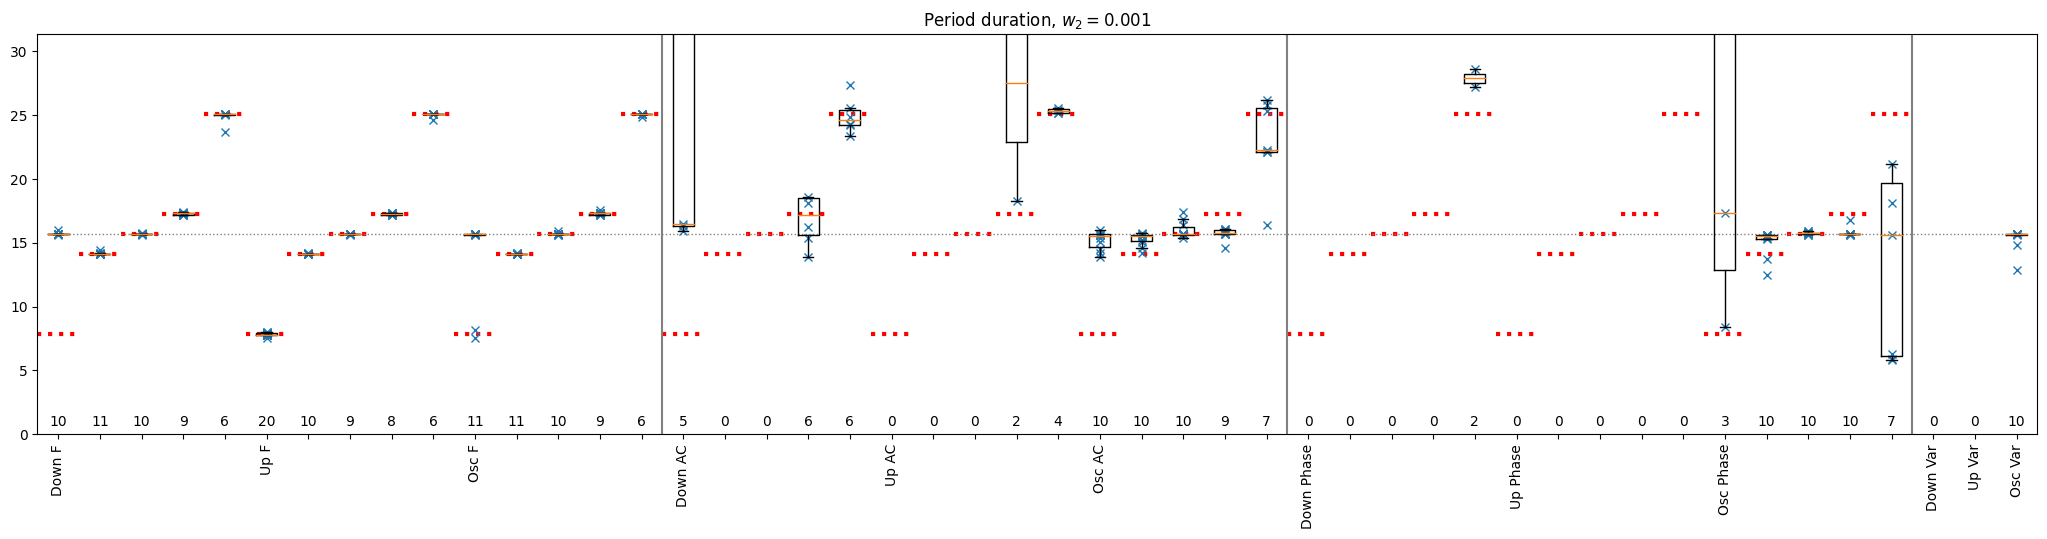

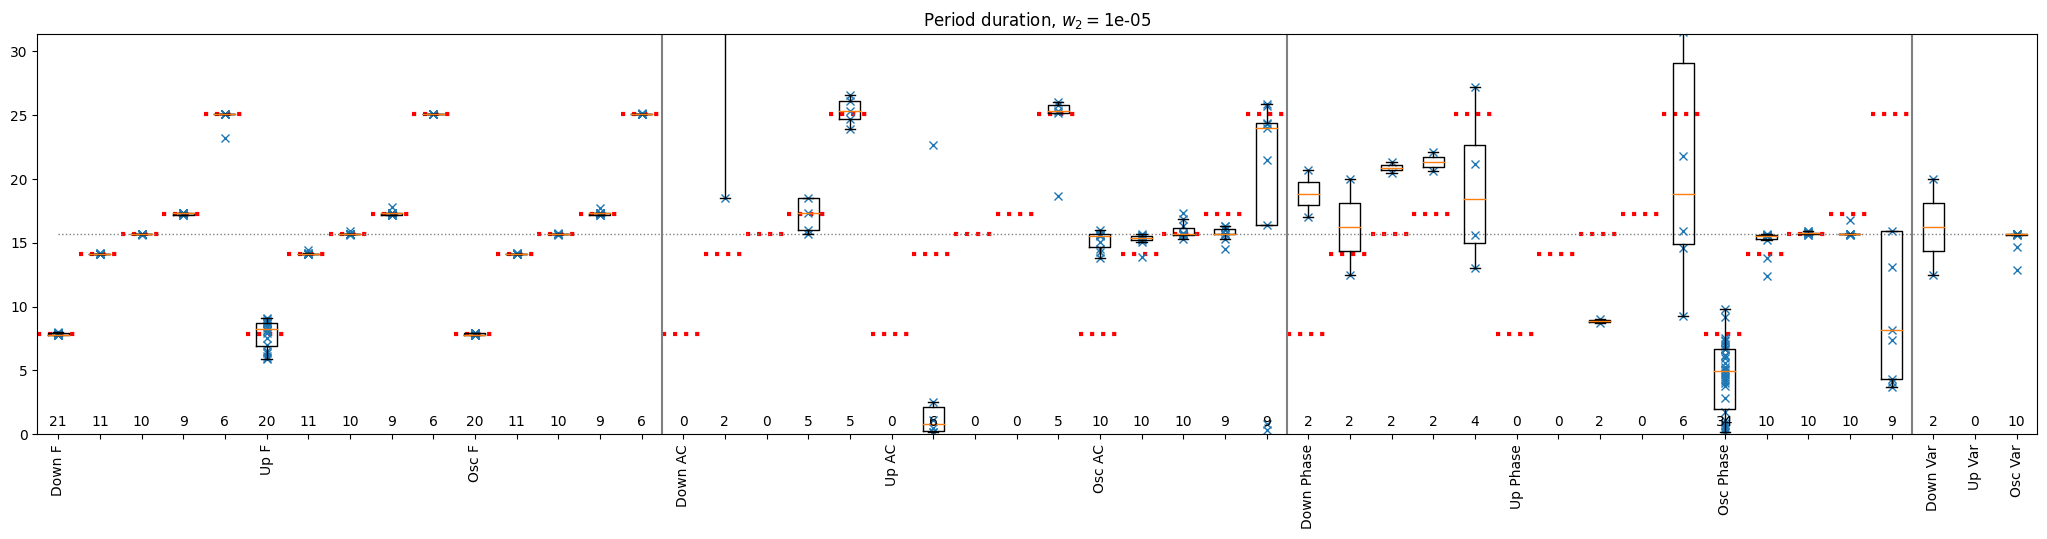

In [ ]:
for iw in range(len(w2_array)):
    ydata = []
    xlabels = []
    fig = plt.figure(figsize =(20, 4))
    ax = fig.add_axes([0, 0, 1, 1])

    xpos = 0

    for imet in range(4):

        for pind in range(len(comp_points)):

            for itar in range(len(target_array)):

                if imet == 3:
                    if itar != 1:
                        continue

                target_period = target_array[itar]
                #xpos = 15*imet + 5*pind + itar

                if imet != 3:
                    if itar != 0:
                        xlabels.append("")
                    else:
                        xlabels.append(xl[imet][pind])
                if imet == 3:
                    xlabels.append(xl[imet][pind])

                data = results["periods"][pind][itar][imet][iw]
                ydata_ = []
                
                if data is None:
                    ydata.append(ydata_)
                    continue

                n_datapoints = 0

                for n in range(N):
                    n_datapoints += len(data[n])
                    
                    if len(data[n]) != 0:
                        for dpoint in data[n]:
                            ax.plot(xpos+1, dpoint, marker="x", color=colors[n])
                            ydata_.append(dpoint)

                ydata.append(ydata_)

                ax.text(xpos+1, 1, str(n_datapoints), horizontalalignment='center', verticalalignment='center')
                if imet != 3: ax.hlines(target_period, xpos+0.5, xpos+1.5, linestyle=":", color="red", linewidth =3)

                xpos += 1


    ax.boxplot(ydata, showfliers=False)
    ax.plot()
    ax.vlines([15.5, 30.5, 45.5], 0., 2.*period, color="grey")
    ax.hlines(period, 1., len(xlabels), linestyle=":", color="grey",linewidth = 1)
    ax.set_xticklabels(xlabels, rotation=90)
    ax.set_ylim(0., 2.*period)
    ax.set_title(r"Period duration, $w_2 = $" + "{}".format(w2_array[iw]))
    plt.show()
    fig.savefig(os.path.join(dir, "periods_" + str(iw) + ".png"), bbox_inches='tight')